# Vision task results

Loads a single `*.run.json` from `run_results/` and plots accuracy across ramp steepnesses.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

import results_utils

RUN_FILE = Path("run_results/AnimalAI_vision_task_control-run_id_Run_1_google_gemini-3-flash-preview.run.json")

In [2]:
df = results_utils.load_run(RUN_FILE)
df.head()

,ramp_height,main,ramp_goal,wall,n_goals,correct,response,input_tokens,output_tokens,latency_ms,model,run_file,trial_id
0,-10,absent,absent,absent,0,0.0,1,1226,1,3767,google/gemini-3-flash-preview,AnimalAI_vision_task_control-run_id_Run_1_goog...,trial_ramp_-10_main_absent_ramp_absent_wall_ab...
1,-2,absent,absent,absent,0,0.0,1,1226,1,10241,google/gemini-3-flash-preview,AnimalAI_vision_task_control-run_id_Run_1_goog...,trial_ramp_-2_main_absent_ramp_absent_wall_abs...
2,-4,absent,absent,absent,0,0.0,1,1226,1,10155,google/gemini-3-flash-preview,AnimalAI_vision_task_control-run_id_Run_1_goog...,trial_ramp_-4_main_absent_ramp_absent_wall_abs...
3,-6,absent,absent,absent,0,0.0,1,1226,1,2729,google/gemini-3-flash-preview,AnimalAI_vision_task_control-run_id_Run_1_goog...,trial_ramp_-6_main_absent_ramp_absent_wall_abs...
4,-8,absent,absent,absent,0,0.0,1,1226,1,4638,google/gemini-3-flash-preview,AnimalAI_vision_task_control-run_id_Run_1_goog...,trial_ramp_-8_main_absent_ramp_absent_wall_abs...


In [3]:
overall = results_utils.overall_accuracy(df)
n_correct = int(df["correct"].sum())
print(f"Overall accuracy: {overall:.2%} ({n_correct}/{len(df)})")

Overall accuracy: 45.45% (5/11)


In [4]:
acc_by_ramp = results_utils.accuracy_by_ramp(df)
acc_by_ramp

,ramp_height,accuracy,n_trials
0,-10,0.0,1
1,-8,0.0,1
2,-6,0.0,1
3,-4,0.0,1
4,-2,0.0,1
5,0,1.0,1
6,2,1.0,1
7,4,1.0,1
8,6,1.0,1
9,8,1.0,1


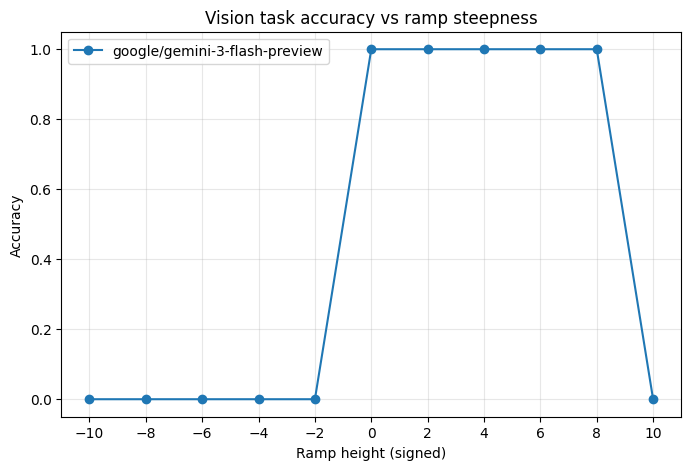

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

for model, group in df.groupby("model"):
    by_ramp = results_utils.accuracy_by_ramp(group)
    ax.plot(by_ramp["ramp_height"], by_ramp["accuracy"], marker="o", label=model)

heights = sorted(df["ramp_height"].unique())
ax.set_xticks(heights)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Ramp height (signed)")
ax.set_ylabel("Accuracy")
ax.set_title("Vision task accuracy vs ramp steepness")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## Combined run: accuracy vs number of goals

Pulls in a second run (one with non-zero goal counts) and plots accuracy against the configured number of goals (0-3, summed across the main / ramp / wall positions). Set `RUN_FILE_2` to the new file once it exists.

In [8]:
import pandas as pd

RUN_FILE_2 = Path("run_results/AnimalAI_vision_task_test-run_id_Run_1_google_gemini-3-flash-preview.run.json") 
df_2 = results_utils.load_run(RUN_FILE_2)
dfs = [df, df_2]
if RUN_FILE_2 != Path("") and RUN_FILE_2.exists():
    dfs.append(df_2)

combined = pd.concat(dfs, ignore_index=True)
combined.groupby("run_file").size()

run_file
AnimalAI_vision_task_control-run_id_Run_1_google_gemini-3-flash-preview.run.json     11
AnimalAI_vision_task_test-run_id_Run_1_google_gemini-3-flash-preview.run.json       572
dtype: int64

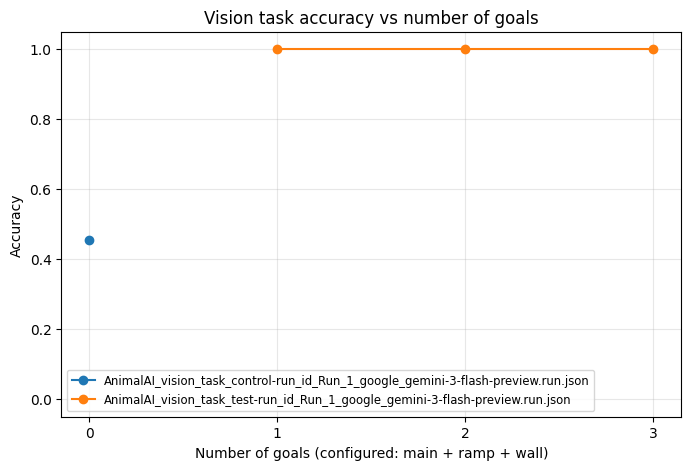

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

for run_file, group in combined.groupby("run_file"):
    by_goals = results_utils.accuracy_by_n_goals(group)
    ax.plot(by_goals["n_goals"], by_goals["accuracy"], marker="o", label=run_file)

ax.set_xticks(sorted(combined["n_goals"].unique()))
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Number of goals (configured: main + ramp + wall)")
ax.set_ylabel("Accuracy")
ax.set_title("Vision task accuracy vs number of goals")
ax.grid(True, alpha=0.3)
ax.legend(fontsize="small")
plt.show()

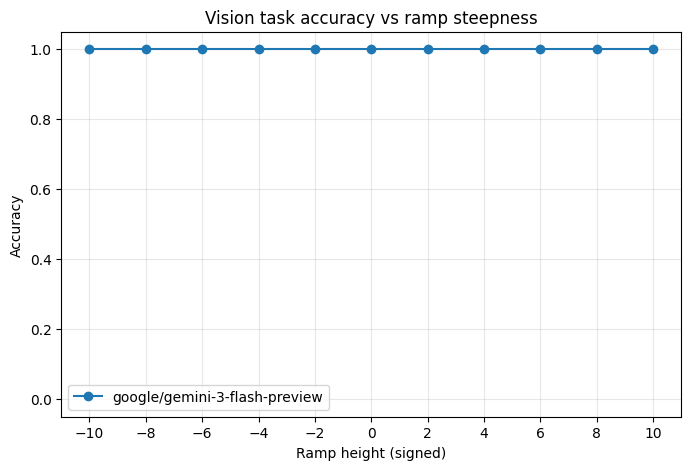

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

for model, group in df_2.groupby("model"):
    by_ramp = results_utils.accuracy_by_ramp(group)
    ax.plot(by_ramp["ramp_height"], by_ramp["accuracy"], marker="o", label=model)

heights = sorted(df_2["ramp_height"].unique())
ax.set_xticks(heights)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Ramp height (signed)")
ax.set_ylabel("Accuracy")
ax.set_title("Vision task accuracy vs ramp steepness")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()